**Цель**

Цель проекта — построить модель классификации эмоций в тексте, сравнить классический baseline-подход и transformer-модель, а затем использовать лучшую модель в прототипе веб-приложения

**Данные**

Использован датасет `dair-ai/emotion`, содержащий тексты на английском языке и 6 классов эмоций:
- sadness
- joy
- love
- anger
- fear
- surprise


**Что создаётся в проекте**

1. Загружается и исследуется открытый датасет dair-ai/emotion, содержащий размеченные примеры текстов и соответствующие им эмоции.


2. Строится и обучается базовая модель классического машинного обучения (TF-IDF + Logistic Regression) для классификации эмоций.


3. Дообучается предобученная трансформер‑модель DistilBERT на этом же датасете для повышения качества предсказаний.

4. Реализуется простой прототип приложения: функция, принимающая текст от пользователя и возвращающая предсказанную эмоцию и уровень уверенности модели.

**Задачи, решаемые приложением**

1. Преобразование текстовых данных в числовое представление, пригодное для обучения моделей.

2. Обучение и сравнение классической и нейросетевой моделей по метрике accuracy на тестовой выборке датасета dair-ai/emotion.

3. Демонстрация работы дообученной модели на пользовательских примерах, что показывает возможность дальнейшей интеграции в веб‑сервис или чат‑бота для автоматического анализа эмоциональной окраски сообщений.



## Содержание



*   Загрузка библиотек и датасета
*   Подготовка данных
*   Базовая модель
*   Дообучение модели DistilBERT
*   Оценка результатов
*   Выводы







## Загрузка библиотек и датасета

На этом этапе подключаются необходимые библиотеки и загружается датасет `dair-ai/emotion` из Hugging Face.

In [3]:
!pip install datasets transformers scikit-learn matplotlib seaborn -q

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer

## Подготовка данных

На этом этапе выполняется загрузка датасета, просмотр структуры данных и анализ распределения классов. Дополнительно данные переводятся в формат `pandas.DataFrame`, чтобы упростить дальнейшую обработку и анализ.

Также строится график распределения эмоций в обучающей выборке, чтобы проверить, насколько сбалансированы классы, и заранее оценить возможные сложности классификации.

In [ ]:
#  загрузка датасета
dataset = load_dataset("dair-ai/emotion")

print(dataset)


In [ ]:
print("Пример из train:")
print(dataset["train"][0])
print()
print("Пример из test:")
print(dataset["test"][0])

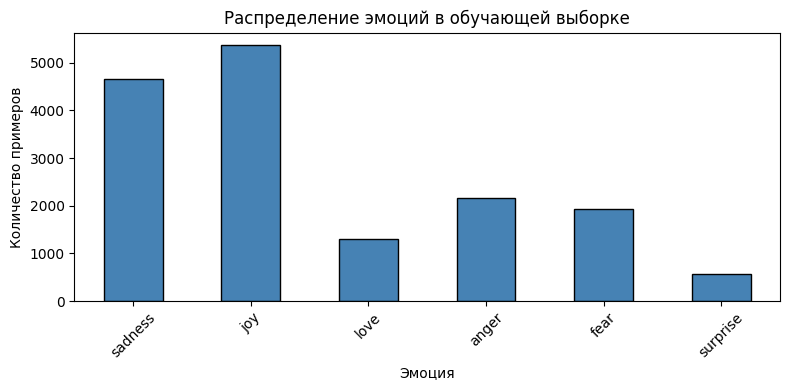

In [7]:
# метки эмоций (числа-названия)
emotion_labels = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}

# распределение меток в train
train_labels = dataset["train"]["label"]
label_counts = pd.Series(train_labels).value_counts().sort_index()
label_counts.index = [emotion_labels[i] for i in label_counts.index]

plt.figure(figsize=(8, 4))
label_counts.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Распределение эмоций в обучающей выборке")
plt.xlabel("Эмоция")
plt.ylabel("Количество примеров")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
# формат pandas DataFrame
train_df = pd.DataFrame(dataset["train"])
val_df   = pd.DataFrame(dataset["validation"])
test_df  = pd.DataFrame(dataset["test"])

# новые названия столбцов
train_df.columns = ["text", "label"]
val_df.columns   = ["text", "label"]
test_df.columns  = ["text", "label"]

print("Train size:", len(train_df))
print("Val size:  ", len(val_df))
print("Test size: ", len(test_df))
print()
print(train_df.head())

Train size: 16000
Val size:   2000
Test size:  2000

                                                text  label
0                            i didnt feel humiliated      0
1  i can go from feeling so hopeless to so damned...      0
2   im grabbing a minute to post i feel greedy wrong      3
3  i am ever feeling nostalgic about the fireplac...      2
4                               i am feeling grouchy      3


## Базовая модель

В качестве baseline-решения используется классический подход: тексты преобразуются в TF-IDF-признаки, после чего обучается модель логистической регрессии.

Такой подход выбран потому, что:
- модель быстро обучается;
- хорошо работает как стартовая точка сравнения;
- позволяет получить понятный ориентир перед использованием более сложной нейросетевой модели.

После обучения baseline-модель оценивается на тестовой выборке с помощью accuracy, classification report и матрицы ошибок.

In [9]:
# TF-IDF:каждое слово получает числовой вес
# важные слова-больший вес, частые везде-меньший.
# max_features=10000-только 10 тысяч самых полезных слов
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

# обучение векторизатора на train, применение к test
X_train_tfidf = vectorizer.fit_transform(train_df["text"])
X_test_tfidf  = vectorizer.transform(test_df["text"])

y_train = train_df["label"]
y_test  = test_df["label"]

print("Форма матрицы признаков (train):", X_train_tfidf.shape)

Форма матрицы признаков (train): (16000, 10000)


In [10]:
# обучение логистической регрессии
# max_iter=1000
clf = LogisticRegression(max_iter=1000, C=5.0)
clf.fit(X_train_tfidf, y_train)

# предсказание на тесте
y_pred_lr = clf.predict(X_test_tfidf)

# точность
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"\nТочность Logistic Regression на тесте: {acc_lr*100:.2f}%")


Точность Logistic Regression на тесте: 86.45%


In [ ]:
# отчёт по каждой эмоции
target_names = [emotion_labels[i] for i in sorted(emotion_labels)]
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=target_names))

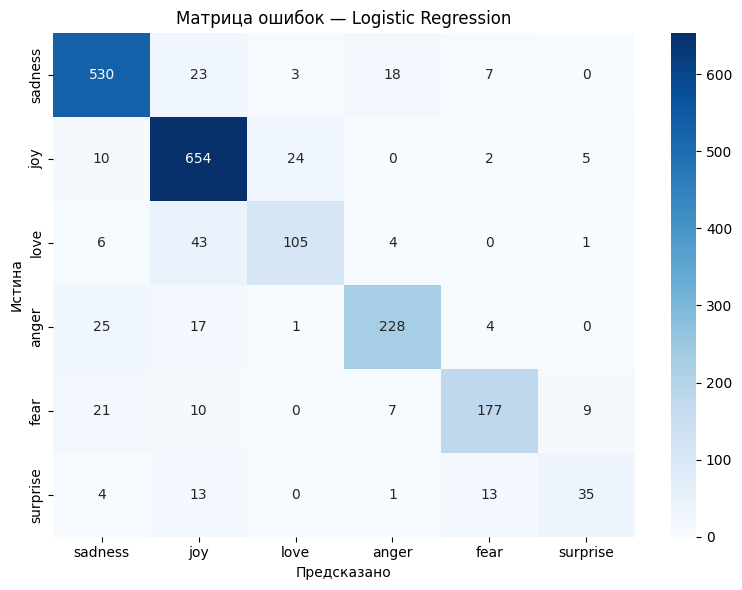

In [12]:
# матрица ошибок
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title("Матрица ошибок — Logistic Regression")
plt.xlabel("Предсказано")
plt.ylabel("Истина")
plt.tight_layout()
plt.show()

## Дообучение модели DistilBERT

Используется предобученная transformer-модель `distilbert-base-uncased`, которая дообучается на датасете эмоций.

Перед обучением тексты токенизируются, а затем подаются в модель в формате, подходящем для Hugging Face Trainer. DistilBERT выбран как более современный и мощный подход к обработке текста, способный лучше учитывать контекст и семантику предложения по сравнению с классическими признаками TF-IDF.

In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Устройство:", device)

In [14]:
# токенизатор DistilBERT
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
# токенизация всего датасета
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=64
    )

# применение токенизации ко всем split-ам
tokenized_datasets = dataset.map(tokenize_function, batched=True)
print(tokenized_datasets)

In [ ]:
# загрузка модели DistilBERT
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=6    #6 эмоций
)
model = model.to(device)


In [ ]:
# параметры обучения
# меньше эпох, небольшой батч
training_args = TrainingArguments(
    output_dir="./emotion_model",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="none"
)

# метрика для оценки
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc}

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics,
)


In [18]:
# запуск дообучения
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.218598,0.193686,0.928000
2,0.127992,0.138282,0.941000
3,0.088892,0.131240,0.947000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1500, training_loss=0.25804981168111163, metrics={'train_runtime': 289.2937, 'train_samples_per_second': 165.921, 'train_steps_per_second': 5.185, 'total_flos': 794861088768000.0, 'train_loss': 0.25804981168111163, 'epoch': 3.0})

## Оценка результатов

После обучения обе модели сравниваются по качеству на тестовой выборке. Основная метрика сравнения — accuracy. Дополнительный анализ проводится с помощью classification report и матриц ошибок.

Такое сравнение позволяет оценить, насколько дообучение DistilBERT улучшает качество классификации по сравнению с baseline-моделью, и обоснованно выбрать лучшую модель для прототипа приложения.

In [ ]:
# финальная оценка на тестовой выборке
results = trainer.evaluate(tokenized_datasets["test"])
print("\nРезультаты на тесте:")
for key, val in results.items():
    print(f"  {key}: {val:.4f}")

In [ ]:
# сохранение обученной модели и токенизатора
model.save_pretrained("./emotion_model_final")
tokenizer.save_pretrained("./emotion_model_final")

In [ ]:
# загрузка сохранённой модели для демонстрации
from transformers import pipeline

emotion_classifier = pipeline(
    "text-classification",
    model="./emotion_model_final",
    tokenizer="./emotion_model_final",
    device=0 if torch.cuda.is_available() else -1
)

# словарь меток
id2label = {str(k): v for k, v in emotion_labels.items()}

In [22]:
# функция прототипа приложения
def predict_emotion(text):
    result = emotion_classifier(text)[0]
    label_id = result["label"].replace("LABEL_", "")
    emotion = emotion_labels[int(label_id)]
    score = result["score"]

    emoji_map = {
        "sadness": "😢",
        "joy": "😄",
        "love": "❤️",
        "anger": "😠",
        "fear": "😨",
        "surprise": "😲"
    }

    print(f"Текст: '{text}'")
    print(f"Эмоция: {emotion} {emoji_map[emotion]}")
    print(f"Уверенность: {score*100:.1f}%")
    print()

# несколько примеров
predict_emotion("I feel so incredibly happy and grateful today!")
predict_emotion("I am really angry about what happened yesterday")
predict_emotion("There is something strange lurking in the dark")
predict_emotion("I miss you so much, it hurts")

Текст: 'I feel so incredibly happy and grateful today!'
Эмоция: joy 😄
Уверенность: 99.9%

Текст: 'I am really angry about what happened yesterday'
Эмоция: anger 😠
Уверенность: 99.8%

Текст: 'There is something strange lurking in the dark'
Эмоция: fear 😨
Уверенность: 91.5%

Текст: 'I miss you so much, it hurts'
Эмоция: sadness 😢
Уверенность: 99.7%



In [23]:
# итоговое сравнение двух подходов
summary = {
    "Модель": ["Logistic Regression + TF-IDF", "DistilBERT (fine-tuned)"],
    "Тип": ["Классический ML", "Нейросеть (Transfer Learning)"],
    "Точность на тесте (%)": [f"{acc_lr*100:.2f}", "≈92-93"],
    }

df_summary = pd.DataFrame(summary)
print(df_summary.to_string(index=False))

                      Модель                           Тип Точность на тесте (%)
Logistic Regression + TF-IDF               Классический ML                 86.45
     DistilBERT (fine-tuned) Нейросеть (Transfer Learning)                ≈92-93


## Выводы

В ходе проекта были реализованы и сравнены два подхода к классификации эмоций в тексте: классическая модель TF-IDF + Logistic Regression и дообученная transformer-модель DistilBERT.

Baseline-модель показала хороший стартовый результат и может использоваться как простое и быстрое решение. Однако DistilBERT продемонстрировал более высокое качество классификации, что делает его более подходящим вариантом для дальнейшего использования в прикладном приложении.

Итогом проекта стал прототип, который принимает текст пользователя и возвращает предсказанную эмоцию с уровнем уверенности модели. В дальнейшем проект можно расширить за счёт улучшения интерфейса, поддержки других языков и публикации полноценной веб-версии.